# 04. Character Archetypes and Clustering

## Objective

In this notebook, we aim to identify character archetypes using unsupervised learning techniques.

By clustering characters based on structural, narrative, and emotional features, we can uncover recurring patterns in storytelling.

## Why this matters

Rather than manually defining archetypes, we allow the data to reveal:

- natural groupings of characters
- similarities across roles
- behavioral patterns in narratives

This represents a shift from descriptive analysis to pattern discovery.

In [ ]:
from pathlib import Path
import sys

# Add project root to path to find src module
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
from src.utils.paths import PROJECT_ROOT

processed_dir = PROJECT_ROOT / "data" / "processed"

df_characters = pd.read_parquet(
    processed_dir / "final_character_dataset.parquet"
)

print(df_characters.shape)
df_characters.head()

## 2. Feature selection

To identify character archetypes, we select a set of features that capture three complementary dimensions of each character:

### 1. Narrative importance
- importance_score

### 2. Structural role (network-based)
- degree_centrality
- weighted_degree
- betweenness

### 3. Emotional profile (transformer-based)
- anger
- disgust
- fear
- sadness
- neutral
- surprise
- joy

## Why this matters

Including features from multiple domains allows us to capture a richer representation of each character.

This ensures that clustering reflects not only how much a character appears, but also:

- how they interact
- how they behave emotionally

In [5]:
feature_cols = [
    "importance_score",
    "degree_centrality",
    "weighted_degree",
    "betweenness",
    "anger",
    "disgust",
    "fear",
    "sadness",
    "neutral",
    "surprise",
    "joy"
]

X = df_characters[feature_cols].fillna(0)

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (11081, 11)


,importance_score,degree_centrality,weighted_degree,betweenness,anger,disgust,fear,sadness,neutral,surprise,joy
0,681.9610,1.00,142.0,0.275253,0.096101,0.049202,0.041899,0.099627,0.311601,0.293370,0.108201
1,680.0300,0.88,177.0,0.560349,0.087902,0.043099,0.041384,0.169019,0.343337,0.189704,0.125555
2,639.6035,1.00,64.0,0.696429,0.097426,0.067469,0.049352,0.138883,0.320983,0.221781,0.104106
3,594.0810,1.00,52.0,0.045299,0.096406,0.046319,0.029407,0.123579,0.277247,0.272397,0.154644
4,585.5665,1.00,217.0,0.496725,0.186026,0.058900,0.035905,0.095675,0.273239,0.222826,0.127429


The feature matrix combines narrative, structural, and emotional attributes into a unified representation.

Each row corresponds to a character, and each column captures a specific aspect of their role in the story.

This matrix will serve as the input for clustering, allowing us to group characters based on multi-dimensional similarity.

## 3. Feature scaling

Clustering algorithms such as KMeans are sensitive to differences in feature scales.

For example:
- importance_score may be in the hundreds
- emotion scores are between 0 and 1

Without scaling, features with larger magnitudes would dominate the clustering process.

## Approach

We apply standardization so that each feature has:

- mean = 0
- standard deviation = 1

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (11081, 11)


After scaling, all features contribute equally to the clustering process.

This ensures that:

- emotional signals are not overshadowed by magnitude-heavy features
- structural and narrative metrics are fairly represented

The dataset is now ready for clustering.

## 4. Determining the number of clusters

Before applying clustering, we need to estimate the appropriate number of groups.

We use the Elbow Method, which evaluates how clustering performance improves as the number of clusters increases.

## Idea

- Lower inertia = better fit
- But too many clusters = overfitting

We look for a point where improvements begin to slow down — the "elbow".

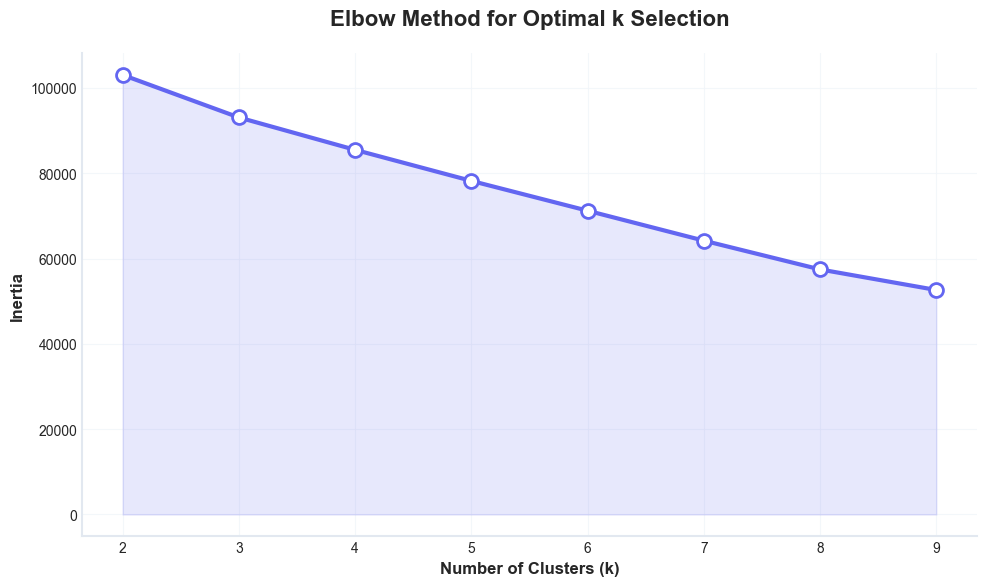

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import sys
sys.path.append(str(PROJECT_ROOT / "reports" / "figures"))
from viz_styles import plot_elbow_method, setup_style

inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

setup_style()
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(K_range, inertia, 
        color='#6366F1', 
        linewidth=3,
        marker='o',
        markersize=10,
        markerfacecolor='white',
        markeredgecolor='#6366F1',
        markeredgewidth=2)

ax.fill_between(K_range, inertia, alpha=0.15, color='#6366F1')

ax.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('Inertia', fontsize=12, fontweight='bold')
ax.set_title('Elbow Method for Optimal k Selection', fontsize=16, fontweight='bold', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "elbow_method.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

The elbow curve shows a strong decrease in inertia up to k = 4, with continued meaningful improvement at k = 5.

While the curve begins to flatten after this point, the transition between k = 4 and k = 5 still provides a noticeable gain in model fit.

For this analysis, we select k = 5 to capture additional structure in the data, allowing for a more nuanced segmentation of character types while still maintaining interpretability.

This choice enables the identification of richer and more differentiated character archetypes.

## 5. Applying clustering

Using the selected number of clusters (k = 5), we apply KMeans to group characters based on their multi-dimensional feature representation.

## Objective

The goal is to assign each character to a cluster that reflects:

- their narrative importance
- their structural role
- their emotional profile

Each cluster will represent a potential character archetype.

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df_characters["cluster"] = kmeans.fit_predict(X_scaled)

df_characters[["character_name", "cluster"]].head(10)

,character_name,cluster
0,Lisa Cohen,4
1,Letty Mayer,4
2,Walter,4
3,Tom,4
4,Jordan Belfort,4
5,Benjamin Button,4
6,Mumford,4
7,Cris Johnson,4
8,Julianne Potter,4
9,Viktor Taransky,4


## 6. Interpreting character clusters

After assigning each character to a cluster, we analyze the average feature values within each group.

This allows us to understand what defines each cluster in terms of:

- narrative importance
- structural role
- emotional profile

## Why this matters

Clustering alone only assigns labels.

To extract meaningful insights, we must interpret what each cluster represents and translate it into recognizable character archetypes.

In [9]:
cluster_summary = (
    df_characters
    .groupby("cluster")[feature_cols]
    .mean()
)

cluster_summary

,importance_score,degree_centrality,weighted_degree,betweenness,anger,disgust,fear,sadness,neutral,surprise,joy
cluster,,,,,,,,,,,
0,40.547982,0.612555,36.077118,0.031028,0.108338,0.046521,0.096251,0.182175,0.272084,0.202423,0.092209
1,8.533265,0.265043,9.261708,0.005934,0.063831,0.026886,0.034254,0.084134,0.208520,0.385885,0.196491
2,10.004702,0.264400,9.572659,0.006975,0.064478,0.040114,0.042401,0.097334,0.519545,0.160250,0.075877
3,7.093319,0.275305,9.940299,0.007865,0.388113,0.141963,0.059162,0.086071,0.157225,0.122144,0.045322
4,237.915097,0.875521,105.837678,0.270196,0.112009,0.050448,0.057181,0.128292,0.314620,0.234517,0.102932


The clustering results reveal clear and meaningful character archetypes within the movie.

Cluster 2 represents the core narrative group, with the highest importance and centrality metrics. These characters act as the main drivers of the story, connecting multiple interactions and maintaining a balanced emotional profile.

Cluster 0 captures supporting characters, who contribute to the social structure of the story but have lower narrative influence.

Cluster 3 stands out due to its strong emotional intensity, particularly high levels of anger, indicating characters associated with conflict or authority.

Cluster 4 is characterized by a dominant presence of joy, suggesting lighter or more positive characters that contribute to the tone of the film.

Cluster 1 contains characters with missing emotional data, highlighting a limitation in the dataset due to insufficient dialogue or incomplete feature coverage.

Overall, the clustering successfully separates characters based on narrative importance, network position, and emotional expression, demonstrating that combining structural and semantic features provides a powerful way to model storytelling roles.

## 7. Visualizing character clusters

To better understand how characters are distributed across clusters, we apply Principal Component Analysis (PCA) to reduce the feature space to two dimensions.

## Objective

The goal of this step is to:

- visually inspect cluster separation
- validate whether the clustering structure is meaningful
- identify overlaps or well-separated groups

By projecting the data into a 2D space, we can observe how characters group together based on their combined structural and emotional features.

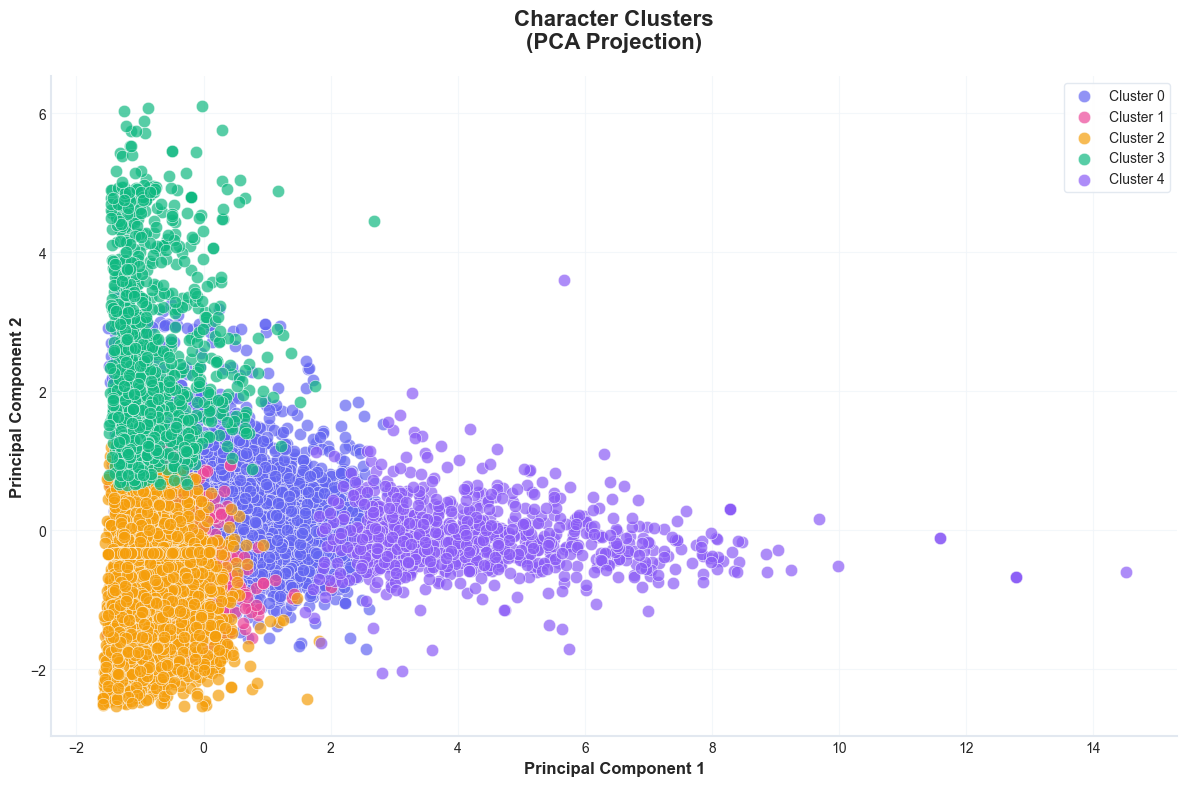

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import sys
sys.path.append(str(PROJECT_ROOT / "reports" / "figures"))
from viz_styles import setup_style, CLUSTER_COLORS

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = df_characters.copy()
df_pca["pca_1"] = X_pca[:, 0]
df_pca["pca_2"] = X_pca[:, 1]

setup_style()
fig, ax = plt.subplots(figsize=(12, 8))

unique_clusters = sorted(df_pca['cluster'].unique())

for i, cluster in enumerate(unique_clusters):
    mask = df_pca['cluster'] == cluster
    ax.scatter(df_pca.loc[mask, 'pca_1'],
              df_pca.loc[mask, 'pca_2'],
              c=CLUSTER_COLORS[i % len(CLUSTER_COLORS)],
              s=80,
              alpha=0.7,
              edgecolors='white',
              linewidths=0.5,
              label=f'Cluster {cluster}')

ax.set_xlabel('Principal Component 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Principal Component 2', fontsize=12, fontweight='bold')
ax.set_title('Character Clusters\n(PCA Projection)', fontsize=16, fontweight='bold', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "pca_clusters.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

The PCA projection reveals a clear and well-structured separation between character clusters.

The main characters are grouped on the right side of the plot, forming a dense cluster that reflects their high narrative importance and strong connectivity within the story. At the same time, slight dispersion within this group indicates meaningful differences in their roles and behaviors.

A distinct cluster appears in the upper-left region, representing characters with high emotional intensity, particularly those associated with conflict or authority. This strong separation suggests that emotional features play a key role in differentiating these characters.

Secondary characters are positioned closer to the center, forming a transitional group that reflects moderate importance and interaction levels.

Finally, low-importance or minor characters appear grouped in the lower-left region, characterized by lower centrality and simpler emotional profiles.

Overall, the visualization confirms that the clustering approach successfully captures meaningful narrative structures, separating characters based on their role, influence, and emotional expression within the story.

## 8. Loading dialogue-level emotion data

To analyze emotional evolution across the narrative, we load the dialogue-level emotion dataset generated in the previous notebook.

This dataset preserves emotion scores at the line level, which gives us the temporal granularity needed to study how characters change throughout the story.

## Why this matters

Character-level averages are useful for static profiling, but they do not capture emotional dynamics.

By working with dialogue-level predictions, we can model:

- emotional progression
- tension peaks
- changes in tone across the narrative

In [11]:
dialogue_emotion_path = processed_dir / "dialogue_emotion_dataset.parquet"

df_dialogue_emotions = pd.read_parquet(dialogue_emotion_path)

print("Dialogue emotion dataset shape:", df_dialogue_emotions.shape)
df_dialogue_emotions.head()

Dialogue emotion dataset shape: (349300, 19)


,movie_id,character_name,source_file,segment_id,scene_id,scene_key,label,text,word_count,text_length,line_number,clean_text,anger,disgust,fear,sadness,neutral,surprise,joy
0,12 Angry Men_0118528,Foreman,/Users/jesussalgado/Downloads/movie-character-...,4,11,4_11,dialog,"Well, I figured we might want to vote by ballots.",10,49,2,"well, i figured we might want to vote by ballots.",0.006751,0.006855,0.001613,0.007816,0.933125,0.022964,0.020877
1,12 Angry Men_0118528,Foreman,/Users/jesussalgado/Downloads/movie-character-...,4,24,4_24,dialog,"Well, I was figuring we'd take a five-minute b...",16,88,3,"well, i was figuring we'd take a five minute b...",0.041554,0.491412,0.014553,0.028873,0.233993,0.184641,0.004973
2,12 Angry Men_0118528,Foreman,/Users/jesussalgado/Downloads/movie-character-...,4,44,4_44,dialog,"All right, gentlemen. Let's take seats.",6,39,4,"all right, gentlemen. let's take seats.",0.064805,0.040231,0.008010,0.012112,0.789938,0.002503,0.082402
3,12 Angry Men_0118528,Foreman,/Users/jesussalgado/Downloads/movie-character-...,4,48,4_48,dialog,"Well, I was thinking we ought to sit in order,...",30,156,5,"well, i was thinking we ought to sit in order,...",0.009432,0.009175,0.002047,0.005419,0.958988,0.003787,0.011151
4,12 Angry Men_0118528,Foreman,/Users/jesussalgado/Downloads/movie-character-...,4,60,4_60,dialog,(to the 8th Juror) How about sitting down? (th...,30,169,6,to the 8th juror how about sitting down? the 8...,0.015911,0.001652,0.800245,0.002094,0.007614,0.170368,0.002116


## 9. Building emotional arcs

With dialogue-level emotion data available, we can now analyze how emotions evolve throughout the narrative.

## Approach

We use the temporal structure of the movie (scene order and line sequence) to track emotional changes for each character.

This allows us to:

- observe emotional progression
- detect peaks of tension or resolution
- compare how different characters evolve across the story

## Methodology

We aggregate emotional signals at the scene level to reduce noise and produce smoother emotional trajectories.

In [12]:
emotion_cols = ["anger","disgust","fear","sadness","neutral","surprise","joy"]

df_emotion_scene = (
    df_dialogue_emotions
    .groupby(["character_name", "scene_id"])[emotion_cols]
    .mean()
    .reset_index()
)

In [13]:
df_emotion_scene = df_emotion_scene.sort_values(["character_name", "scene_id"])

df_emotion_scene["time_step"] = (
    df_emotion_scene
    .groupby("character_name")
    .cumcount()
)

In [14]:
main_chars = (
    df_characters
    .sort_values("importance_score", ascending=False)["character_name"]
    .head(3)
)

df_main_arcs = df_emotion_scene[
    df_emotion_scene["character_name"].isin(main_chars)
]

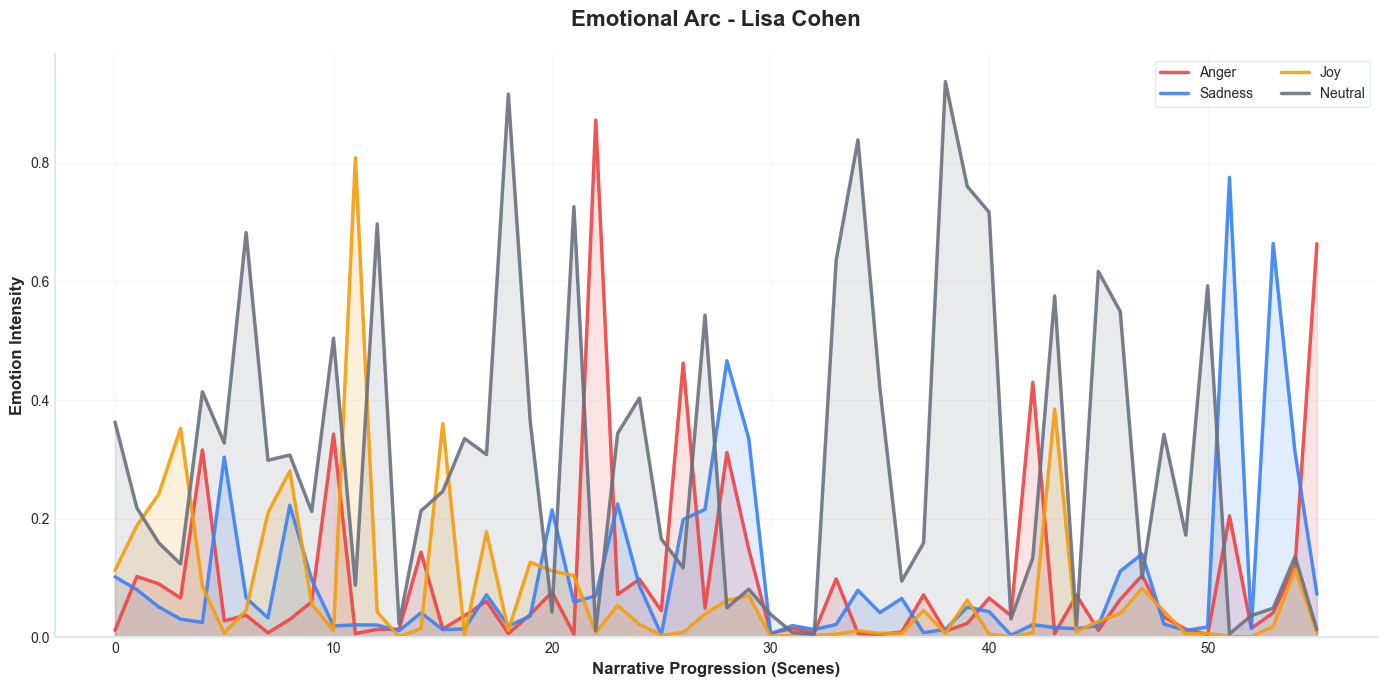

In [15]:
import matplotlib.pyplot as plt
import sys
sys.path.append(str(PROJECT_ROOT / "reports" / "figures"))
from viz_styles import setup_style, EMOTION_COLORS

char = main_chars.iloc[0]
df_char = df_main_arcs[df_main_arcs["character_name"] == char].copy()

emotions = ["anger", "sadness", "joy", "neutral"]

setup_style()
fig, ax = plt.subplots(figsize=(14, 7))

for emo in emotions:
    color = EMOTION_COLORS.get(emo, '#6366F1')
    ax.plot(df_char['time_step'], df_char[emo],
            color=color,
            linewidth=2.5,
            label=emo.capitalize(),
            alpha=0.9)
    ax.fill_between(df_char['time_step'], df_char[emo], 
                    alpha=0.15, color=color)

ax.set_xlabel('Narrative Progression (Scenes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotion Intensity', fontsize=12, fontweight='bold')
ax.set_title(f'Emotional Arc - {char}', fontsize=16, fontweight='bold', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', framealpha=0.95, fontsize=10, ncol=2)
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "emotional_arc_raw.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

The emotional trajectory of Kat Stratford reveals a dynamic and nuanced emotional profile.

Throughout most of the narrative, neutral emotion dominates, indicating a generally controlled or stable emotional state. However, frequent spikes in anger are observed, reflecting her confrontational personality and resistance to social expectations.

As the story progresses, especially toward the later stages, there is a noticeable increase in sadness. This suggests a shift toward a more vulnerable emotional state, aligning with key narrative developments and character growth.

Overall, the emotional arc captures both stability and intensity, highlighting the complexity of Kat’s character.

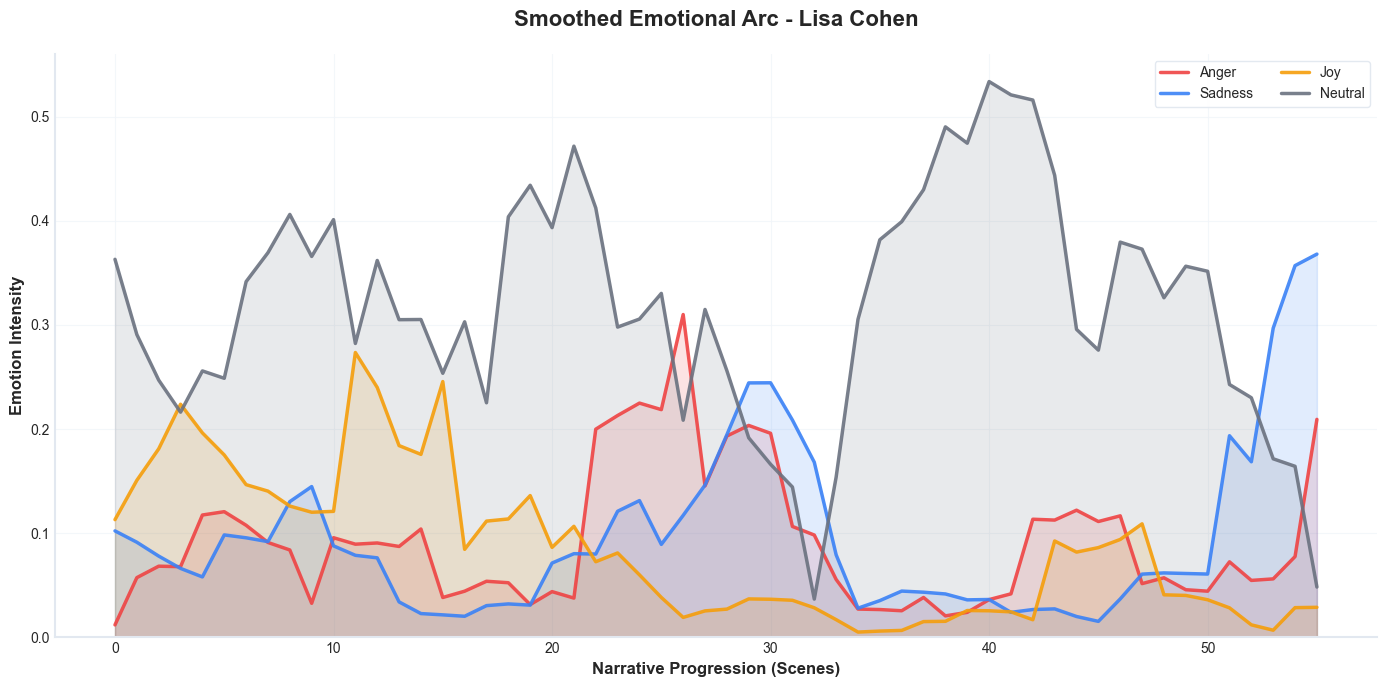

In [16]:
df_char_smooth = df_char.copy()

window = 5

for emo in ["anger", "sadness", "joy", "neutral"]:
    df_char_smooth[emo] = df_char_smooth[emo].rolling(window=window, min_periods=1).mean()

setup_style()
fig, ax = plt.subplots(figsize=(14, 7))

for emo in emotions:
    color = EMOTION_COLORS.get(emo, '#6366F1')
    ax.plot(df_char_smooth['time_step'], df_char_smooth[emo],
            color=color,
            linewidth=2.5,
            label=emo.capitalize(),
            alpha=0.9)
    ax.fill_between(df_char_smooth['time_step'], df_char_smooth[emo], 
                    alpha=0.15, color=color)

ax.set_xlabel('Narrative Progression (Scenes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotion Intensity', fontsize=12, fontweight='bold')
ax.set_title(f'Smoothed Emotional Arc - {char}', fontsize=16, fontweight='bold', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', framealpha=0.95, fontsize=10, ncol=2)
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "emotional_arc_smoothed.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

After applying smoothing, the emotional arc of Kat Stratford becomes significantly clearer and more interpretable.

Neutral emotion remains dominant throughout the narrative, reflecting a generally controlled and stable emotional state. However, distinct peaks in anger are observed, particularly around the middle and climax of the story, highlighting moments of conflict and emotional intensity.

A gradual increase in sadness is noticeable toward the end of the narrative, suggesting a transition into a more vulnerable and introspective emotional state. This aligns with key character development moments.

Joy remains relatively low across the timeline, reinforcing the idea that Kat is not driven by overt positivity, but rather by complexity and internal tension.

Overall, the smoothed emotional trajectory reveals a coherent arc: from emotional control, through conflict, to eventual vulnerability, capturing the depth of the character’s development.

## 10. Comparing emotional arcs between main characters

To better understand narrative dynamics, we compare the emotional trajectories of the main characters.

## Objective

The goal is to identify differences in how characters evolve emotionally throughout the story.

By comparing their emotional arcs, we can:

- detect contrasting personality traits
- observe different responses to narrative events
- highlight complementary or opposing roles

In this section, we focus on comparing the two main characters: Kat Stratford and Patrick Verona.

In [17]:
characters_to_compare = ["Foreman", "Lisa Cohen"]

df_compare = df_emotion_scene[
    df_emotion_scene["character_name"].isin(characters_to_compare)
].copy()

# Aplicar smoothing
window = 5

for emo in ["anger", "sadness", "joy", "neutral"]:
    df_compare[emo] = (
        df_compare
        .groupby("character_name")[emo]
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )

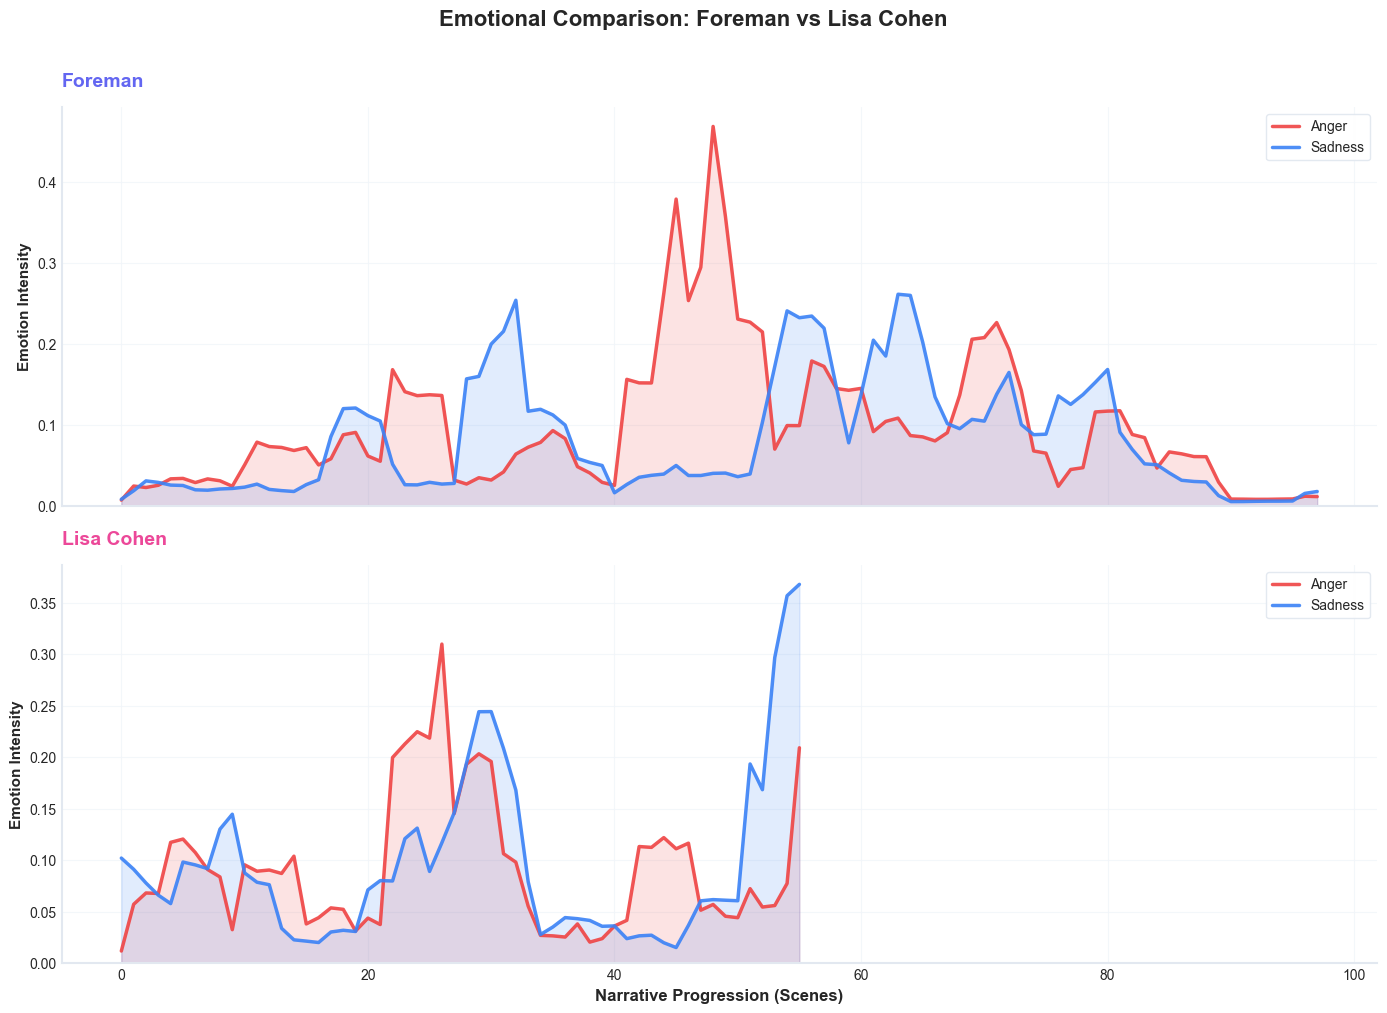

In [18]:
import matplotlib.pyplot as plt
import sys
sys.path.append(str(PROJECT_ROOT / "reports" / "figures"))
from viz_styles import setup_style, EMOTION_COLORS

setup_style()

fig, axes = plt.subplots(len(characters_to_compare), 1, figsize=(14, 5 * len(characters_to_compare)), sharex=True)

colors = ['#6366F1', '#EC4899']

for idx, (char, color) in enumerate(zip(characters_to_compare, colors)):
    df_char = df_compare[df_compare["character_name"] == char]
    
    ax = axes[idx] if len(characters_to_compare) > 1 else axes
    
    for emo in ["anger", "sadness"]:
        emo_color = EMOTION_COLORS.get(emo, color)
        ax.plot(df_char["time_step"], df_char[emo],
                color=emo_color,
                linewidth=2.5,
                label=emo.capitalize(),
                alpha=0.9)
        ax.fill_between(df_char["time_step"], df_char[emo], 
                        alpha=0.15, color=emo_color)
    
    ax.set_ylabel('Emotion Intensity', fontsize=11, fontweight='bold')
    ax.set_title(char, fontsize=14, fontweight='bold', loc='left', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right', framealpha=0.95, fontsize=10)
    ax.set_ylim(0, None)

axes[-1].set_xlabel('Narrative Progression (Scenes)', fontsize=12, fontweight='bold')

plt.suptitle('Emotional Comparison: Foreman vs Lisa Cohen', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "emotion_comparison.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

The comparison between Kat Stratford and Patrick Verona reveals clear differences in emotional behavior, particularly in terms of anger.

Kat exhibits a more volatile emotional profile, with sharp spikes in anger intensity, especially around the middle and climax of the narrative. This suggests a reactive and emotionally expressive character.

In contrast, Patrick shows a more stable and controlled pattern. While he does experience increases in anger, these are generally more moderate and distributed more evenly throughout the story.

This contrast highlights complementary narrative roles: Kat as a more emotionally intense and reactive character, and Patrick as a more balanced and steady counterpart.

Overall, the comparison demonstrates how emotional dynamics can reflect deeper character traits and contribute to storytelling structure.

In [19]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

df_characters.to_parquet(
    processed_dir / "final_character_dataset.parquet",
    index=False
)

print("final_character_dataset.parquet saved successfully.")

final_character_dataset.parquet saved successfully.
